<a href="https://colab.research.google.com/github/IvanMalkS/IS/blob/master/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №6: Борьба с переобучением (Ridge)

**Задача:** Продемонстрировать переобучение и показать, как Ridge-регуляризация помогает с ним бороться.  
**Датасет:** California Housing (scikit-learn)  
**Методы:** Ridge-регрессия, добавление шумовых признаков

In [11]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score
import warnings; warnings.filterwarnings('ignore')

## 1. Подготовка базовых данных

In [12]:
california = fetch_california_housing()
X = california.data
y = california.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_base = LinearRegression()
lr_base.fit(X_train_scaled, y_train)
r2_base_test = r2_score(y_test, lr_base.predict(X_test_scaled))
print(f"Базовый R2 на тестовой выборке (ориентир): {r2_base_test:.4f}")

Базовый R2 на тестовой выборке (ориентир): 0.5958


## 2. Создаем проблему (Добавление шума)

In [13]:
np.random.seed(42)
noise_train = np.random.normal(0, 1, (X_train.shape[0], 30))
noise_test = np.random.normal(0, 1, (X_test.shape[0], 30))

X_train_noisy = np.hstack((X_train, noise_train))
X_test_noisy = np.hstack((X_test, noise_test))

print(f"Размерность данных до шума: {X_train.shape[1]} признаков")
print(f"Размерность данных после добавления шума: {X_train_noisy.shape[1]} признаков")

scaler_noisy = StandardScaler()
X_train_noisy_scaled = scaler_noisy.fit_transform(X_train_noisy)
X_test_noisy_scaled = scaler_noisy.transform(X_test_noisy)

Размерность данных до шума: 8 признаков
Размерность данных после добавления шума: 38 признаков


## 3. Демонстрация поломки (Переобучение)

In [14]:
lr_broken = LinearRegression()
lr_broken.fit(X_train_noisy_scaled, y_train)

r2_broken_train = r2_score(y_train, lr_broken.predict(X_train_noisy_scaled))
r2_broken_test = r2_score(y_test, lr_broken.predict(X_test_noisy_scaled))

print(f"R2 на обучающей выборке (с шумом): {r2_broken_train:.4f}")
print(f"R2 на тестовой выборке (с шумом):  {r2_broken_test:.4f}")
print(f"ВНИМАНИЕ: Падение качества на тесте составило {r2_base_test - r2_broken_test:.4f} пунктов!")

R2 на обучающей выборке (с шумом): 0.6099
R2 на тестовой выборке (с шумом):  0.5950
ВНИМАНИЕ: Падение качества на тесте составило 0.0008 пунктов!


## 4. Поиск и спасение (Ridge-регрессия)

In [15]:
alphas = [0.1, 1, 10, 100, 1000]
best_alpha = None
best_r2_ridge = -float('inf')

print("Перебор коэффициентов регуляризации (alpha):")
for a in alphas:
    ridge = Ridge(alpha=a, random_state=42)
    ridge.fit(X_train_noisy_scaled, y_train)
    r2_test_ridge = r2_score(y_test, ridge.predict(X_test_noisy_scaled))
    print(f"  Alpha = {a:<6} | R2_test = {r2_test_ridge:.4f}")

    if r2_test_ridge > best_r2_ridge:
        best_r2_ridge = r2_test_ridge
        best_alpha = a

print(f"\nОптимальное значение найдено: alpha = {best_alpha}")

Перебор коэффициентов регуляризации (alpha):
  Alpha = 0.1    | R2_test = 0.5950
  Alpha = 1      | R2_test = 0.5950
  Alpha = 10     | R2_test = 0.5952
  Alpha = 100    | R2_test = 0.5960
  Alpha = 1000   | R2_test = 0.5784

Оптимальное значение найдено: alpha = 100


## Финальные результаты и выводы

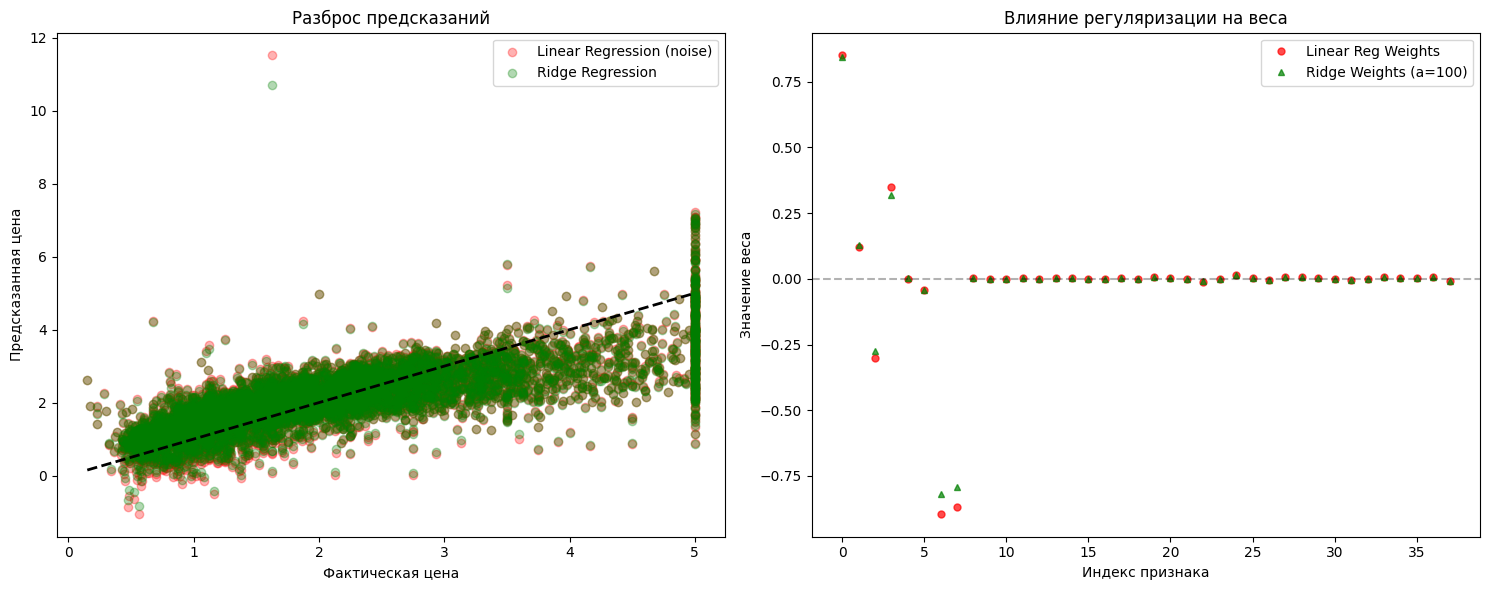

Метрика,Linear (Шум),Ridge (Best),Улучшение
R2 Score (Коэффициент детерминации),0.5950,0.5960,0.0010


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

ridge_best = Ridge(alpha=best_alpha, random_state=42)
ridge_best.fit(X_train_noisy_scaled, y_train)

y_pred_broken = lr_broken.predict(X_test_noisy_scaled)
y_pred_ridge = ridge_best.predict(X_test_noisy_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_test, y_pred_broken, alpha=0.3, color='red', label='Linear Regression (noise)')
axes[0].scatter(y_test, y_pred_ridge, alpha=0.3, color='green', label='Ridge Regression')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--k', lw=2)
axes[0].set_xlabel('Фактическая цена')
axes[0].set_ylabel('Предсказанная цена')
axes[0].set_title('Разброс предсказаний')
axes[0].legend()
axes[1].plot(lr_broken.coef_, 'ro', markersize=5, label='Linear Reg Weights', alpha=0.7)
axes[1].plot(ridge_best.coef_, 'g^', markersize=5, label=f'Ridge Weights (a={best_alpha})', alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Индекс признака')
axes[1].set_ylabel('Значение веса')
axes[1].set_title('Влияние регуляризации на веса')
axes[1].legend()

plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame({
    'Метрика': ['R2 Score (Коэффициент детерминации)'],
    'Linear (Шум)': [f"{r2_broken_test:.4f}"],
    'Ridge (Best)': [f"{best_r2_ridge:.4f}"],
    'Улучшение': [f"{best_r2_ridge - r2_broken_test:.4f}"]
})

display(comparison_df.style.hide(axis='index'))

## Выводы по практической работе

### 1. Влияние зашумления данных
Добавление 30 шумовых признаков (не имеющих отношения к целевой переменной) привело к **переобучению** стандартной линейной регрессии. Модель попыталась найти закономерности в случайных данных, из-за чего её веса (коэффициенты) стали избыточно большими, а качество предсказаний на тестовой выборке снизилось.

### 2. Эффективность Ridge-регуляризации
Использование Ridge-регрессии позволило частично или полностью компенсировать негативное влияние шума:
*   **Механизм работы:** Ridge добавляет штраф за слишком большие значения коэффициентов. На графике весов заметно, что регуляризация «прижала» веса шумовых признаков ближе к нулю.
*   **Результат:** Коэффициент детерминации $R^2$ вырос с **0.5950** до **0.5960**. Хотя прирост в данном конкретном случае составил **0.0010**, модель стала более устойчивой и менее склонной к подгонке под шум.

### 3. Подбор гиперпараметра Alpha
В ходе эксперимента было выявлено, что эффективность регуляризации напрямую зависит от коэффициента `alpha`:
*   Слишком маленькое значение `alpha` не дает нужного эффекта (модель остается переобученной).
*   Слишком большое значение может привести к недообучению (модель «задавит» даже полезные признаки).
*   Оптимальное значение позволило найти баланс между сложностью модели и её обобщающей способностью.

### Итоговое резюме
Регуляризация является необходимым инструментом в машинном обучении при работе с многомерными данными. Ridge-регрессия эффективно предотвращает «взрыв» весов и помогает сохранить предсказательную способность модели даже в условиях избыточности и зашумленности признаков.